In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# --- 1. Data Loading, Encoding, and Splitting ---
df = pd.read_excel("../data/Dry_Bean_Dataset.xlsx")

# Encode string labels into integers (0, 1, 2, ...)
y_encoded, y_labels = pd.factorize(df['Class'])
X = df.drop('Class', axis=1)

# Stratified three-way split
X_train_full, X_remainder, y_train_full, y_remainder = train_test_split(
    X, y_encoded, test_size=0.33, stratify=y_encoded, random_state=42
)
X_cv, X_test, y_cv, y_test = train_test_split(
    X_remainder, y_remainder, test_size=0.5, stratify=y_remainder, random_state=42
)

In [3]:
# --- 2. Train the Full 16-Feature Model (For Accuracy Chart) ---
model_full = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2", 
        solver="lbfgs", 
        max_iter=5000, 
        multi_class="multinomial",
        random_state=42
    ))
])
model_full.fit(X_train_full, y_train_full)

/mnt/d/Uni/ML/dry-bean-classification/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,steps,"[('scaler', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


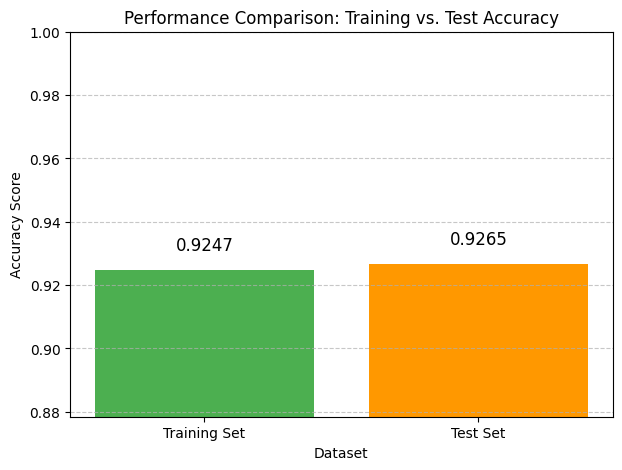

In [4]:
# --- 3. Accuracy Comparison Bar Chart Generation ---
y_train_pred = model_full.predict(X_train_full)
acc_train = accuracy_score(y_train_full, y_train_pred)
y_test_pred = model_full.predict(X_test)
acc_test = accuracy_score(y_test, y_test_pred)

scores = [acc_train, acc_test]
labels = ['Training Set', 'Test Set']

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, scores, color=['#4CAF50', '#FF9800']) 
plt.ylim(min(scores) * 0.95, 1.0) 
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}', ha='center', va='bottom', fontsize=12)

plt.title('Performance Comparison: Training vs. Test Accuracy')
plt.ylabel('Accuracy Score')
plt.xlabel('Dataset')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show() # Display the bar chart


In [5]:
# --- 4. Decision Boundary Plot Generation ---
# a) PCA Transformation (16D to 2D)
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_full)
X_test_2d = pca.transform(X_test)

# b) 2D Model Training (for visualization only)
model_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(multi_class="multinomial", solver="saga", max_iter=2000, random_state=42))
])
model_2d.fit(X_train_2d, y_train_full)

/mnt/d/Uni/ML/dry-bean-classification/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,steps,"[('scaler', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [6]:
# c) Define Meshgrid (Fixed MemoryError: Step size 0.1)
x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 10), 
                     np.arange(y_min, y_max, 10))

# d) Predict and Reshape Z
Z_grid = np.c_[xx.ravel(), yy.ravel()]
Z = model_2d.predict(Z_grid)
Z = Z.reshape(xx.shape)

/tmp/ipykernel_1905/3719988966.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  contour = plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.get_cmap('Spectral', num_classes))
/tmp/ipykernel_1905/3719988966.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('Spectral', num_classes), s=30)
/tmp/ipykernel_1905/3719988966.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('Spectral', num_classes))
/tmp/ipykernel_1905/371

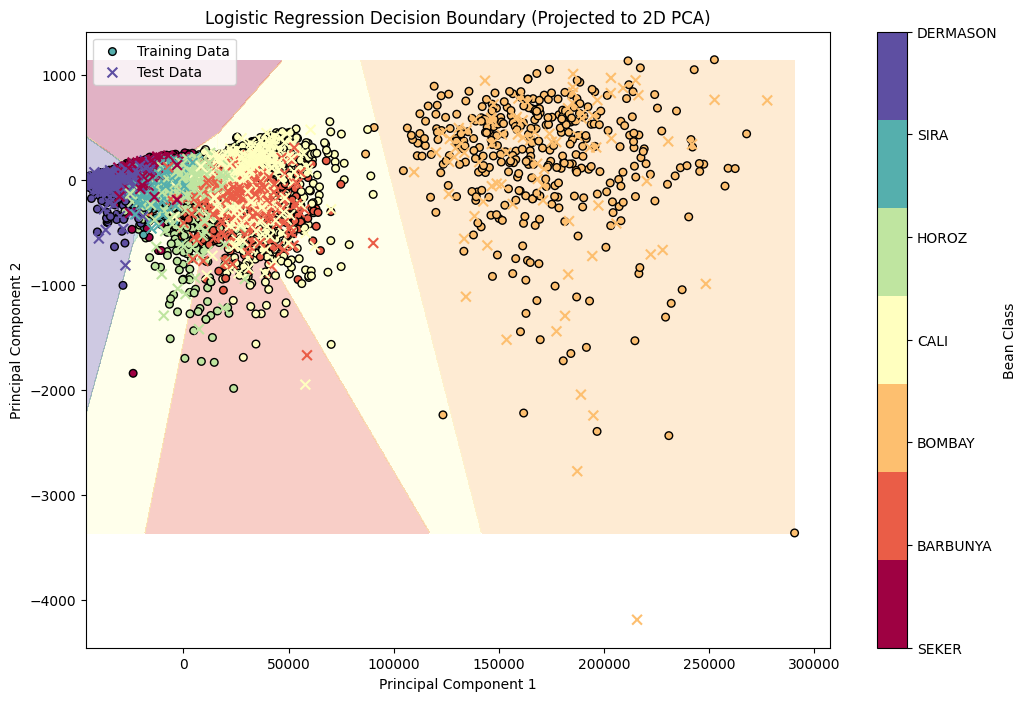

In [7]:
# e) Plotting the boundary and data points
plt.figure(figsize=(12, 8))
num_classes = len(y_labels)

contour = plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.get_cmap('Spectral', num_classes))

scatter_train = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], 
                            c=y_train_full, 
                            marker='o', edgecolor='k', label='Training Data', 
                            cmap=plt.cm.get_cmap('Spectral', num_classes), s=30)

plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], 
            c=y_test, 
            marker='x', s=50, linewidths=1.5, edgecolor='k', label='Test Data', 
            cmap=plt.cm.get_cmap('Spectral', num_classes))

plt.title('Logistic Regression Decision Boundary (Projected to 2D PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()

cbar = plt.colorbar(scatter_train, ticks=np.arange(num_classes))
cbar.set_ticklabels(y_labels)
cbar.set_label('Bean Class')
plt.show() # Display the decision boundary plot